In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms.v2 as tfs

## Классная работа

### реализована в классификации MNIST

## Домашняя работа

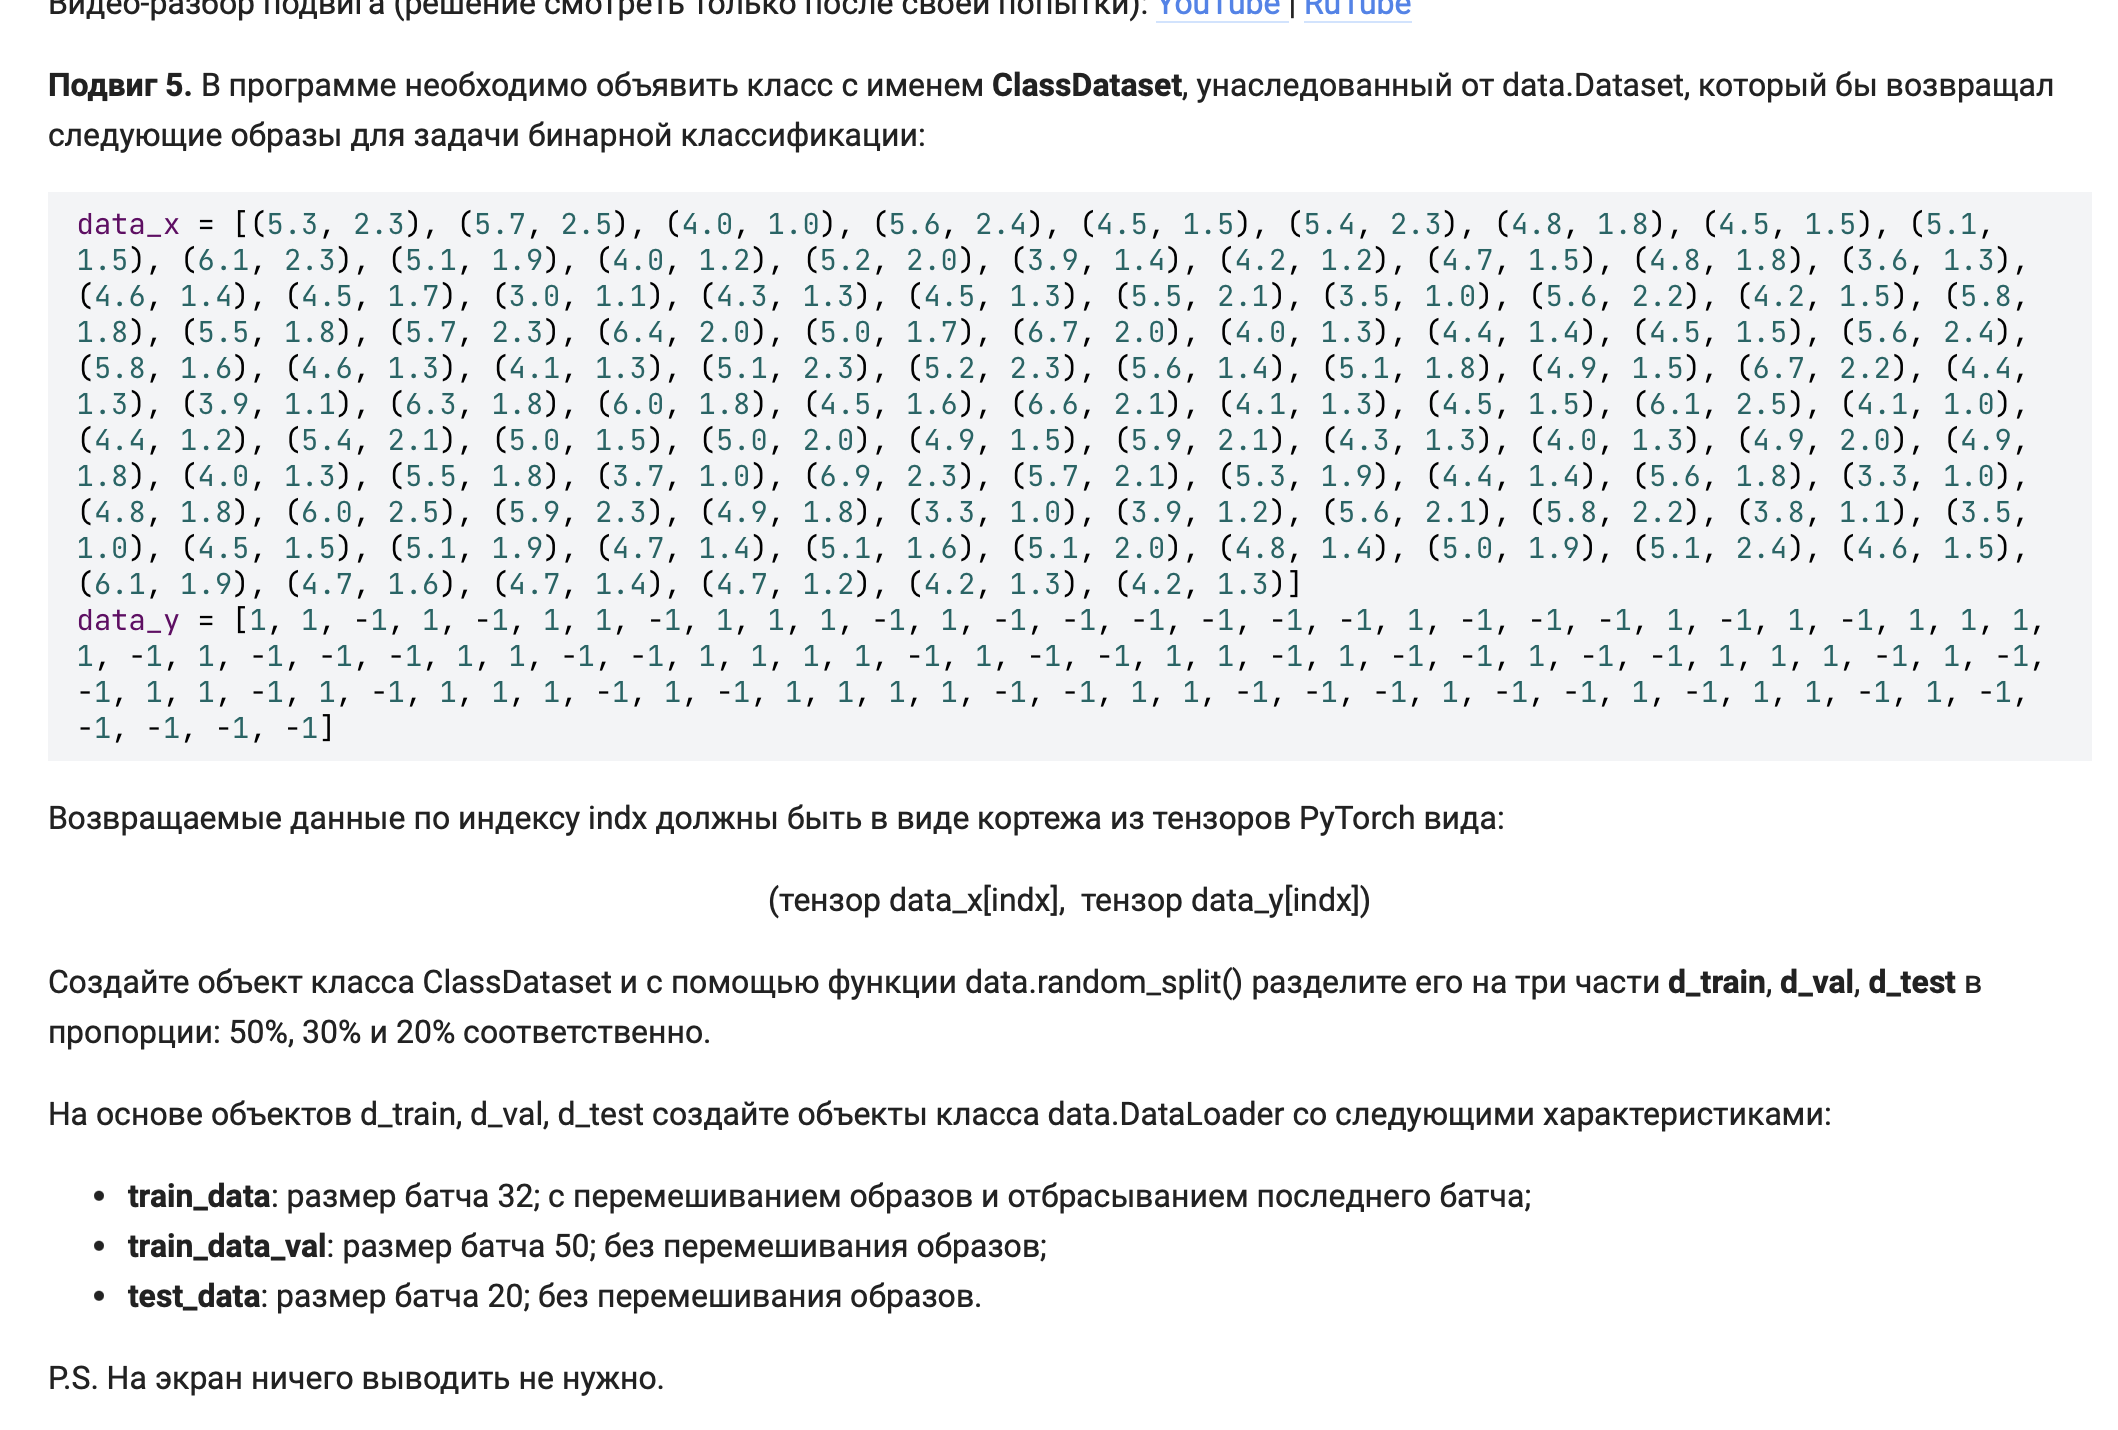

In [ ]:
class ClassDataset(data.Dataset):
    def __init__(self):
        data_x = [(5.3, 2.3), (5.7, 2.5), (4.0, 1.0), (5.6, 2.4), (4.5, 1.5), (5.4, 2.3), (4.8, 1.8), (4.5, 1.5), (5.1, 1.5), (6.1, 2.3), (5.1, 1.9), (4.0, 1.2), (5.2, 2.0), (3.9, 1.4), (4.2, 1.2), (4.7, 1.5), (4.8, 1.8), (3.6, 1.3), (4.6, 1.4), (4.5, 1.7), (3.0, 1.1), (4.3, 1.3), (4.5, 1.3), (5.5, 2.1), (3.5, 1.0), (5.6, 2.2), (4.2, 1.5), (5.8, 1.8), (5.5, 1.8), (5.7, 2.3), (6.4, 2.0), (5.0, 1.7), (6.7, 2.0), (4.0, 1.3), (4.4, 1.4), (4.5, 1.5), (5.6, 2.4), (5.8, 1.6), (4.6, 1.3), (4.1, 1.3), (5.1, 2.3), (5.2, 2.3), (5.6, 1.4), (5.1, 1.8), (4.9, 1.5), (6.7, 2.2), (4.4, 1.3), (3.9, 1.1), (6.3, 1.8), (6.0, 1.8), (4.5, 1.6), (6.6, 2.1), (4.1, 1.3), (4.5, 1.5), (6.1, 2.5), (4.1, 1.0), (4.4, 1.2), (5.4, 2.1), (5.0, 1.5), (5.0, 2.0), (4.9, 1.5), (5.9, 2.1), (4.3, 1.3), (4.0, 1.3), (4.9, 2.0), (4.9, 1.8), (4.0, 1.3), (5.5, 1.8), (3.7, 1.0), (6.9, 2.3), (5.7, 2.1), (5.3, 1.9), (4.4, 1.4), (5.6, 1.8), (3.3, 1.0), (4.8, 1.8), (6.0, 2.5), (5.9, 2.3), (4.9, 1.8), (3.3, 1.0), (3.9, 1.2), (5.6, 2.1), (5.8, 2.2), (3.8, 1.1), (3.5, 1.0), (4.5, 1.5), (5.1, 1.9), (4.7, 1.4), (5.1, 1.6), (5.1, 2.0), (4.8, 1.4), (5.0, 1.9), (5.1, 2.4), (4.6, 1.5), (6.1, 1.9), (4.7, 1.6), (4.7, 1.4), (4.7, 1.2), (4.2, 1.3), (4.2, 1.3)]
        data_y = [1, 1, -1, 1, -1, 1, 1, -1, 1, 1, 1, -1, 1, -1, -1, -1, -1, -1, -1, 1, -1, -1, -1, 1, -1, 1, -1, 1, 1, 1, 1, -1, 1, -1, -1, -1, 1, 1, -1, -1, 1, 1, 1, 1, -1, 1, -1, -1, 1, 1, -1, 1, -1, -1, 1, -1, -1, 1, 1, 1, -1, 1, -1, -1, 1, 1, -1, 1, -1, 1, 1, 1, -1, 1, -1, 1, 1, 1, 1, -1, -1, 1, 1, -1, -1, -1, 1, -1, -1, 1, -1, 1, 1, -1, 1, -1, -1, -1, -1, -1]
        self.x = torch.tensor(data_x)
        self.y = torch.tensor(data_y)

    def __getitem__(self, item):
        return self.x[item], self.y[item]
    
    def __len__(self):
        return len(self.x)

d_all = ClassDataset()
d_train, d_val, d_test = data.random_split(d_all, [0.5, 0.3, 0.2])

train_data = data.DataLoader(d_train, batch_size=32, shuffle=True, drop_last=True)
train_data_val = data.DataLoader(d_val, batch_size=50, shuffle=False)
test_data = data.DataLoader(d_test, batch_size=20, shuffle=False)

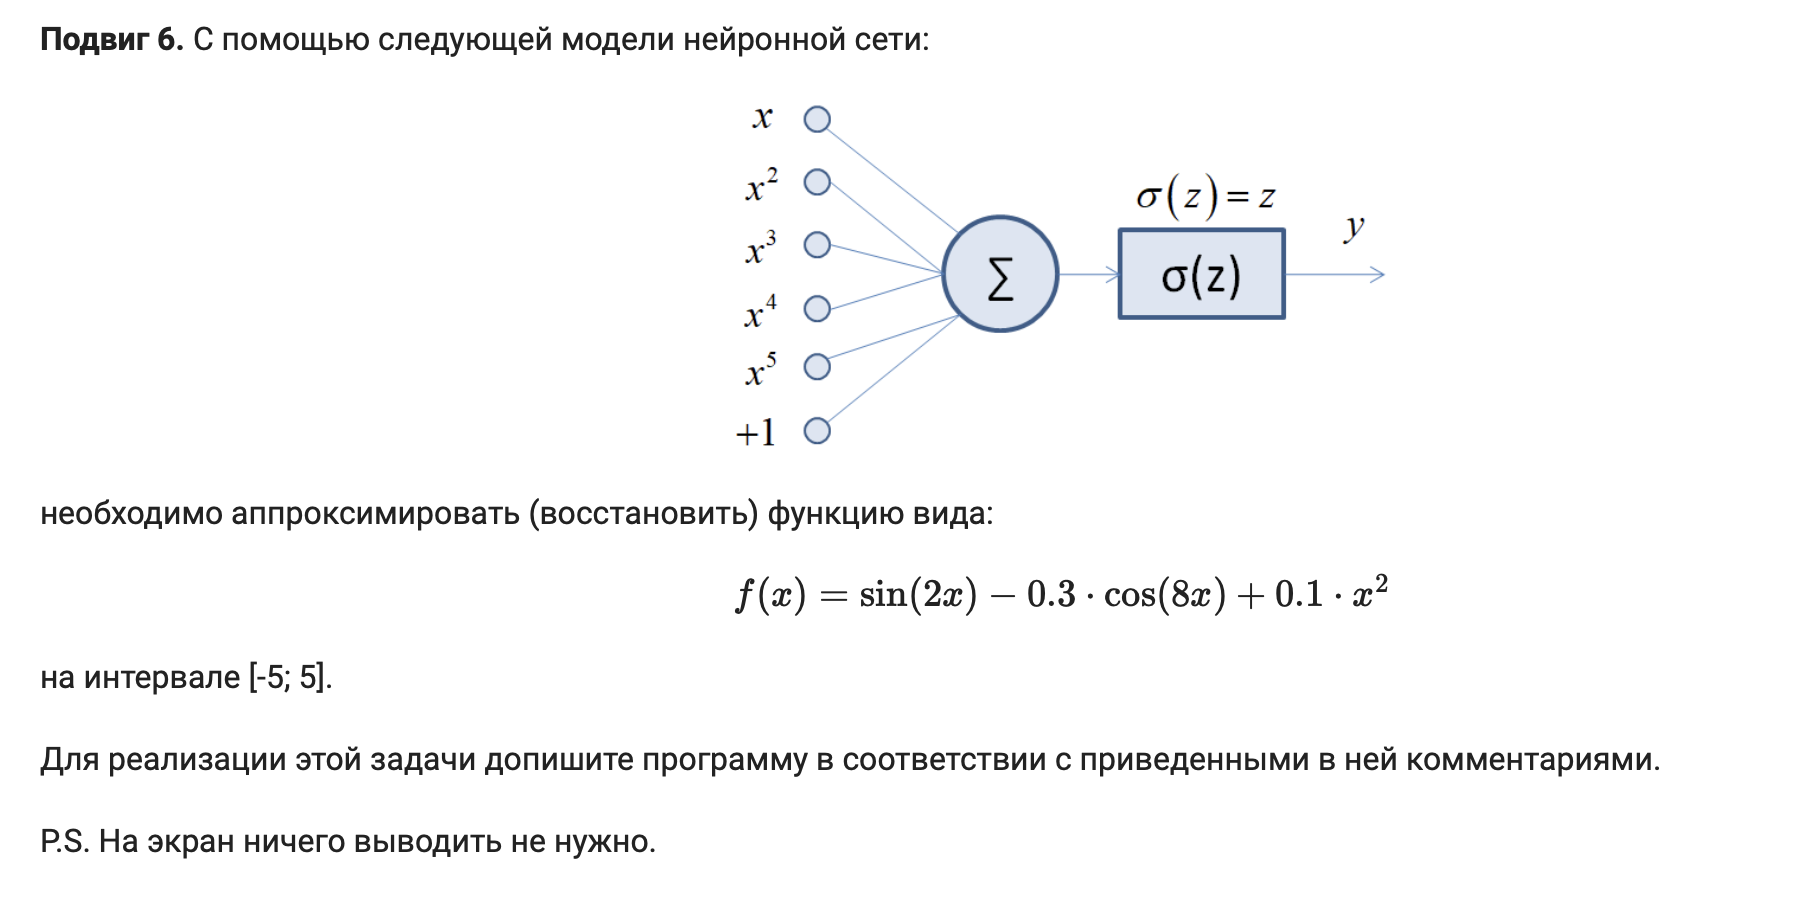

In [5]:
class FuncModel(nn.Module):
    def __init__(self):
        super().__init__()
        # модель однослойной полносвязной нейронной сети:
        # 1-й слой: число входов 5 (x, x^2, x^3, x^4, x^5), число нейронов 1
        self.layer = nn.Linear(5, 1)

    def forward(self, x):
        x.unsqueeze_(-1)
        xx = torch.cat([x, x ** 2, x ** 3, x ** 4, x ** 5], dim=1)
        y = self.layer(xx)
        return y


torch.manual_seed(1)

model = FuncModel() # создать модель FuncModel

epochs = 20 # число эпох обучения
batch_size = 16 # размер батча

# данные обучающей выборки (значения функции)
data_x = torch.arange(-5, 5, 0.05) #тензоры data_x, data_y не менять
data_y = torch.sin(2 * data_x) - 0.3 * torch.cos(8 * data_x) + 0.1 * data_x ** 2

ds = data.TensorDataset(data_x, data_y) # создание dataset
d_train, d_val = data.random_split(ds, [0.7, 0.3]) # разделить ds на две части в пропорции: 70% на 30%
train_data = data.DataLoader(d_train, batch_size, shuffle=True) # создать объект класса DataLoader для d_train с размером пакетов batch_size и перемешиванием образов выборки
train_data_val = data.DataLoader(d_val, batch_size, shuffle=False) # создать объект класса DataLoader для d_val с размером пакетов batch_size и без перемешивания образов выборки

optimizer = optim.RMSprop(model.parameters(), lr=0.01) # создать оптимизатор RMSprop для обучения модели с шагом обучения 0.01
loss_func = nn.MSELoss() # создать функцию потерь с помощью класса MSELoss

loss_lst_val = []  # список значений потерь при валидации
loss_lst = []  # список значений потерь при обучении

for _e in range(epochs):
    # перевести модель в режим обучения
    model.train()

    loss_mean = 0 # вспомогательные переменные для вычисления среднего значения потерь при обучении
    lm_count = 0

    for x_train, y_train in train_data:
        predict = model(x_train) # вычислить прогноз модели для данных x_train
        loss = loss_func(predict.squeeze(), y_train) # вычислить значение функции потерь

        # сделать один шаг градиентного спуска для корректировки параметров модели
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # вычисление среднего значения функции потерь по всей выборке
        lm_count += 1
        loss_mean = 1 / lm_count * loss.item() + (1 - 1 / lm_count) * loss_mean

    # валидация модели
    # перевести модель в режим эксплуатации
    model.eval()
    Q_val = 0
    count_val = 0

    for x_val, y_val in train_data_val:
        with torch.no_grad():
            # для x_val, y_val вычислить потери с помощью функции loss_func
            pred = model(x_val)
            loss = loss_func(pred.squeeze(), y_val)
            count_val += 1
            Q_val += loss

    # сохранить средние потери, вычисленные по выборке валидации, в переменной Q_val
    Q_val /= count_val

    loss_lst.append(loss_mean)
    loss_lst_val.append(Q_val)

# перевести модель в режим эксплуатации
model.eval()
# выполнить прогноз модели по всем данным выборки (data_x)
Q = loss_func(model(data_x).squeeze(), data_y).item() # вычислить потери с помощью loss_func по всем данным выборки data_x; значение Q сохранить в виде вещественного числа
Q

17.375410079956055

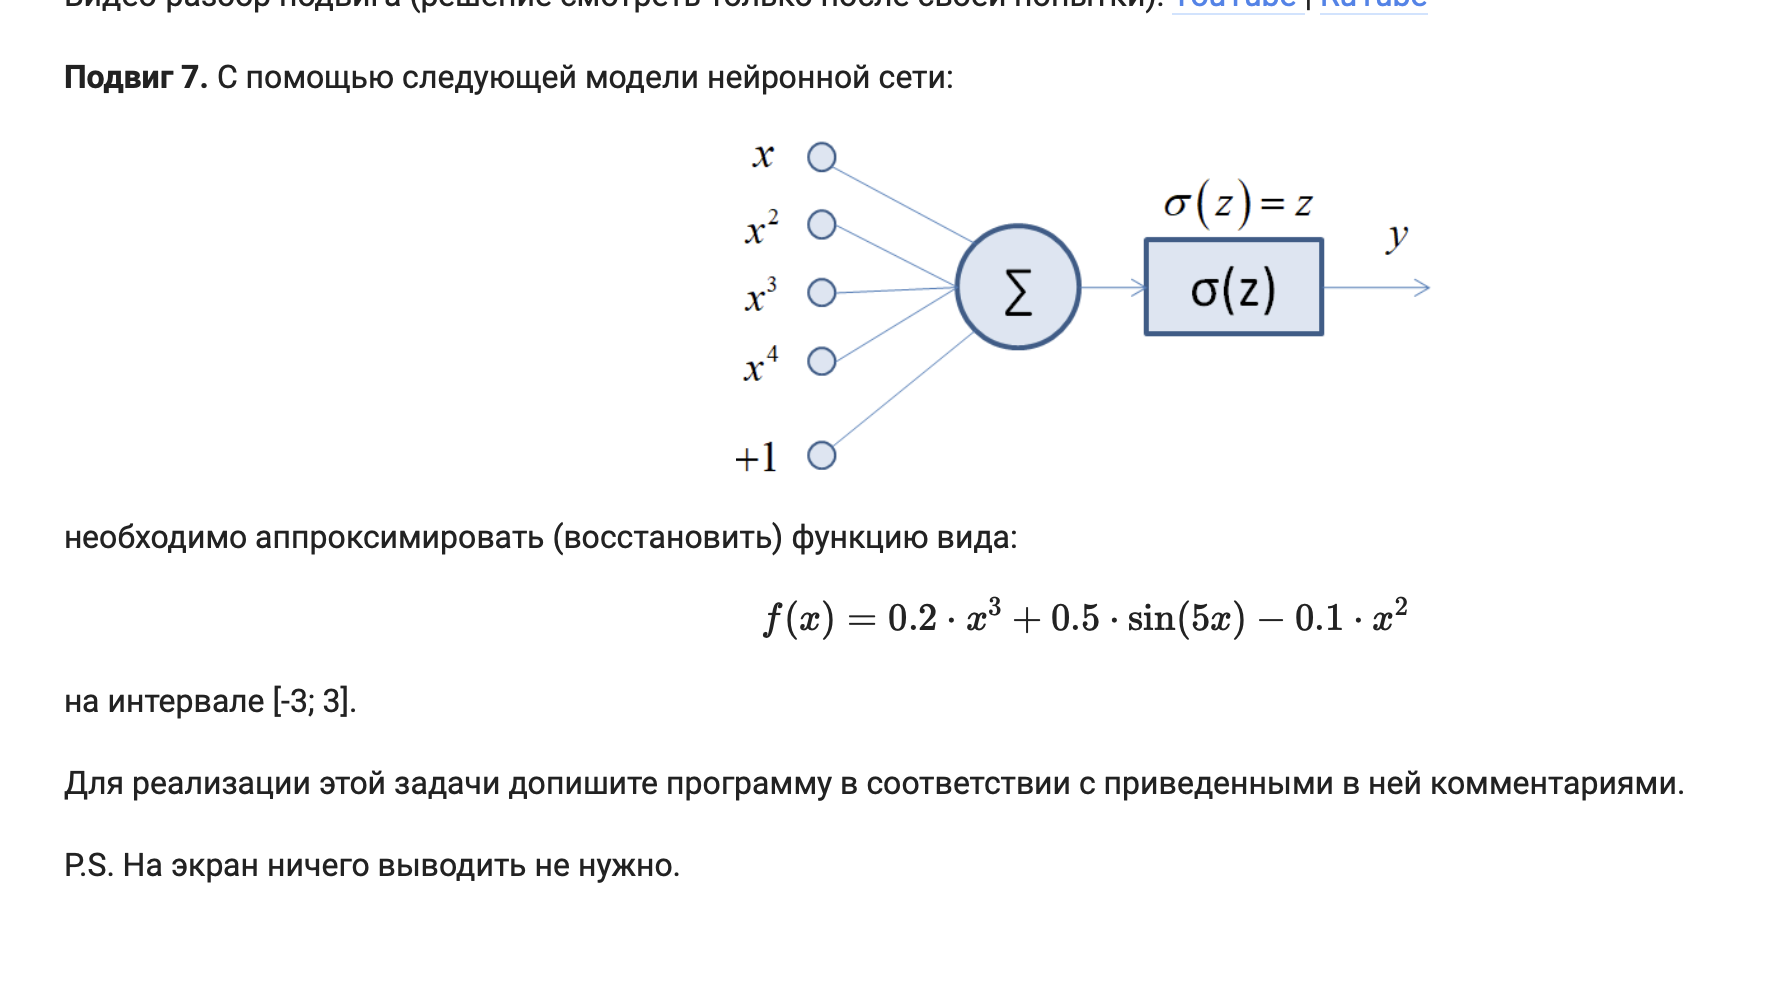

In [ ]:
class FuncModel(nn.Module):
    def __init__(self):
        super().__init__()
        # модель однослойной полносвязной нейронной сети:
        # 1-й слой: число входов 4 (x, x^2, x^3, x^4), число нейронов 1
        self.l1 = nn.Linear(4, 1)

    def forward(self, x):
        # реализация модели нейронной сети
        x.unsqueeze_(-1)
        xx = torch.cat([x, x**2, x**3, x**4], dim=1)
        y = self.l1(xx)

        return y

torch.manual_seed(1)

model = FuncModel() # создать модель FuncModel

epochs = 15 # число эпох обучения
batch_size = 32 # размер батча

# создание обучающей выборки (значения функции)
data_x = torch.arange(-3, 3, 0.01) #тензоры data_x, data_y не менять
data_y = 0.2 * data_x ** 3 + 0.5 * torch.sin(5 * data_x) - 0.1 * data_x ** 2

ds = data.TensorDataset(data_x, data_y) # создание dataset
d_train, d_val = data.random_split(ds, [0.8, 0.2]) # разделить ds на две части в пропорции: 80% на 20%
train_data = data.DataLoader(d_train, batch_size, shuffle=True) # создать объект класса DataLoader для d_train с размером пакетов batch_size и перемешиванием образов выборки
train_data_val = data.DataLoader(d_val, batch_size, shuffle=False) # создать объект класса DataLoader для d_val с размером пакетов batch_size и без перемешивания образов выборки

optimizer = optim.Adam(model.parameters(), lr=0.01) # создать оптимизатор Adam для обучения модели с шагом обучения 0.01
loss_func = nn.MSELoss() # создать функцию потерь с помощью класса MSELoss

loss_lst_val = []  # список значений потерь при валидации
loss_lst = []  # список значений потерь при обучении

for _e in range(epochs):
    model.train()
    loss_mean = 0 # вспомогательные переменные для вычисления среднего значения потерь при обучении
    lm_count = 0

    # обучение нейронной сети с вычисление средних потерь loss_mean
    for x_train, y_train in train_data:
        pred = model(x_train)
        loss = loss_func(pred.squeeze(), y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        lm_count += 1
        loss_mean += loss.item()

    loss_mean /= lm_count

    # валидация нейронной сети с вычислением средних потерь Q_val
    model.eval()
    Q_val = 0
    count = 0
    for x_val, y_val in train_data_val:
        with torch.no_grad():
            pred = model(x_val)
            loss = loss_func(pred.squeeze(), y_val)

            Q_val += loss.item()
            count += 1

    Q_val /= count

    # добавление в списки вычисленных значений потерь
    loss_lst.append(loss_mean)
    loss_lst_val.append(Q_val)

# перевести модель в режим эксплуатации
# выполнить прогноз модели по всем данным выборки (ds.data)
Q = loss_func(model(data_x).squeeze(), data_y).item() # вычислить потери с помощью loss_func по всем данным выборки ds; значение Q сохранить в виде вещественного числа
Q

0.22382019460201263